In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('interactions_export.csv')
df.head()

,id,timestamp,user_text,assistant_response,tools_called,stt_seconds,brain_seconds,tts_seconds,total_seconds,success,trigger_mode,is_test
0,18,2026-09-13T15:19:21.931211+00:00,tell me about what is a AI?,Artificial Intelligence (AI) refers to the dev...,[],2.5831,3.7132,14.5847,20.8811,1,wake_word,0
1,19,2026-09-13T15:19:43.228118+00:00,Can you open Instagram?,"Now that Instagram is open, I can assist you w...","[""open_application""]",2.3509,4.2018,8.6860,15.2387,1,conversation,0
2,20,2026-09-13T15:20:00.747450+00:00,in the app go to the message section,You are now in the Messages section of Instagr...,"[""find_and_click_element""]",2.4906,5.4269,5.3173,13.2348,1,conversation,0
3,21,2026-09-13T15:20:58.944131+00:00,"Can you tell me how much, how many unrated mes...",It seems like Instagram doesn't provide a dire...,"[""find_and_click_element"", ""run_python""]",2.6940,8.8335,38.7346,50.2620,1,conversation,0
4,22,2026-09-13T15:21:17.561244+00:00,in F go to the real section,You are now in the Reels section of Instagram....,"[""find_and_click_element""]",2.4339,5.1511,5.2300,12.8150,1,conversation,0


In [4]:
print(f"Total interactions: {len(df)}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nSuccess rate: {df['success'].mean():.1%}")
print(f"\nTrigger mode breakdown:")
print(df['trigger_mode'].value_counts())

Total interactions: 39
Date range: 2026-09-13T15:19:21.931211+00:00 to 2026-09-15T11:01:26.405352+00:00

Success rate: 100.0%

Trigger mode breakdown:
trigger_mode
conversation    22
wake_word       17
Name: count, dtype: int64


Average latency per stage (seconds):
stt_seconds      2.268787
brain_seconds    4.477882
tts_seconds      8.256256
dtype: float64

Total time spent per stage across all 39 interactions:
stt_seconds       88.4827
brain_seconds    174.6374
tts_seconds      321.9940
dtype: float64


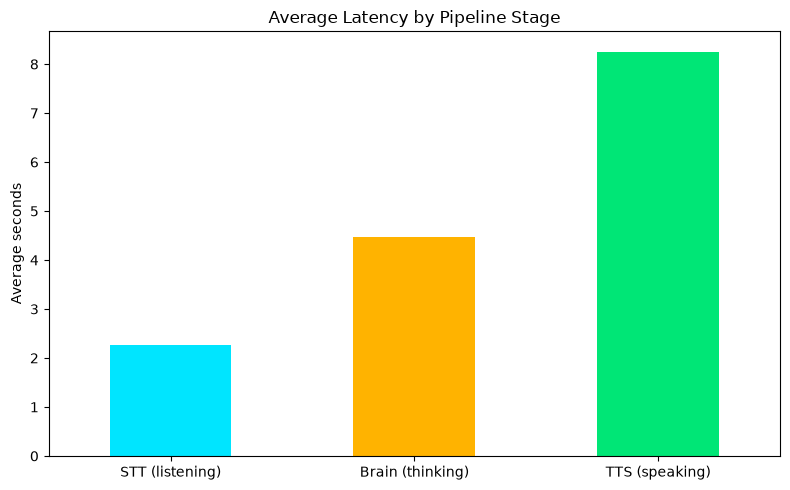

In [5]:
latency_cols = ['stt_seconds', 'brain_seconds', 'tts_seconds']
latency_means = df[latency_cols].mean()
latency_totals = df[latency_cols].sum()

print("Average latency per stage (seconds):")
print(latency_means)
print(f"\nTotal time spent per stage across all {len(df)} interactions:")
print(latency_totals)

fig, ax = plt.subplots(figsize=(8, 5))
latency_means.plot(kind='bar', ax=ax, color=['#00e5ff', '#ffb300', '#00e676'])
ax.set_ylabel('Average seconds')
ax.set_title('Average Latency by Pipeline Stage')
ax.set_xticklabels(['STT (listening)', 'Brain (thinking)', 'TTS (speaking)'], rotation=0)
plt.tight_layout()
plt.show()

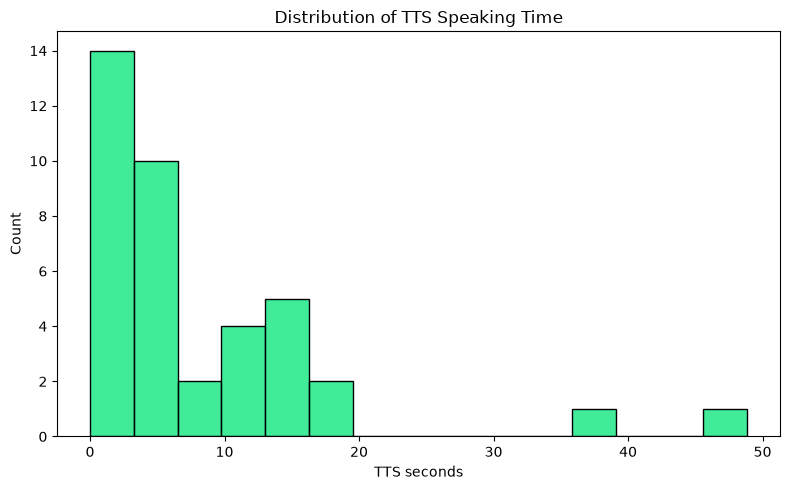

Top 5 longest TTS responses:
                                            user_text  tts_seconds  \
12          What can you tell me about this internet?      48.8522   
3   Can you tell me how much, how many unrated mes...      38.7346   
24                          What is machine learning?      18.9074   
19                                            Though.      18.5687   
14                            go to the real section.      16.2764   

    total_seconds  
12        57.3175  
3         50.2620  
24        25.0173  
19        25.2418  
14        27.6049  


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['tts_seconds'], bins=15, ax=ax, color='#00e676')
ax.set_xlabel('TTS seconds')
ax.set_title('Distribution of TTS Speaking Time')
plt.tight_layout()
plt.show()

print("Top 5 longest TTS responses:")
print(df.nlargest(5, 'tts_seconds')[['user_text', 'tts_seconds', 'total_seconds']])

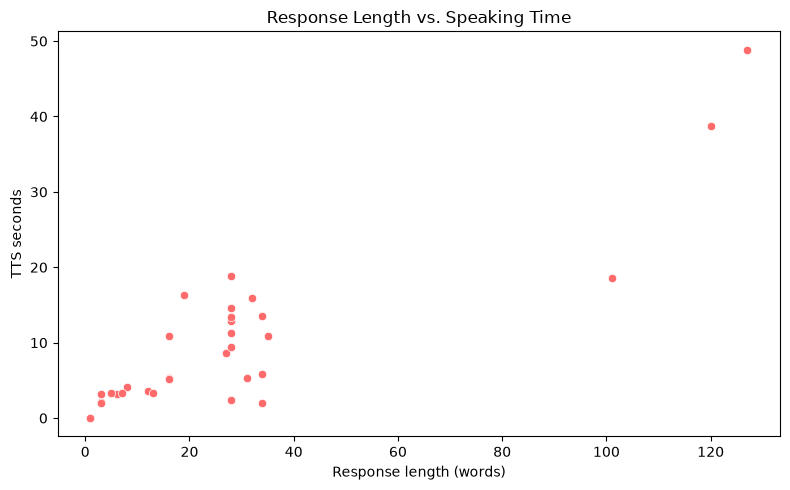

                                            user_text  response_word_count  \
12          What can you tell me about this internet?                  127   
3   Can you tell me how much, how many unrated mes...                  120   
19                                            Though.                  101   
5                                Hold down this rail.                   35   
11                        Can you tell me what is AI?                   34   

    tts_seconds  
12      48.8522  
3       38.7346  
19      18.5687  
5       10.8474  
11      13.5717  


In [7]:
df['response_word_count'] = df['assistant_response'].str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='response_word_count', y='tts_seconds', ax=ax, color='#ff6b6b')
ax.set_xlabel('Response length (words)')
ax.set_ylabel('TTS seconds')
ax.set_title('Response Length vs. Speaking Time')
plt.tight_layout()
plt.show()

print(df[['user_text', 'response_word_count', 'tts_seconds']].sort_values('response_word_count', ascending=False).head(5))

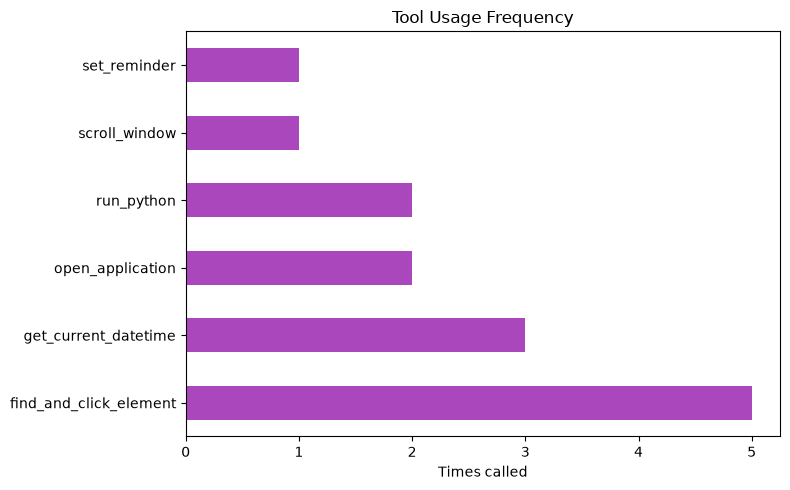

find_and_click_element    5
get_current_datetime      3
open_application          2
run_python                2
scroll_window             1
set_reminder              1
dtype: int64


In [8]:
from collections import Counter
import ast

all_tools = []
for tools_str in df['tools_called']:
    tools = ast.literal_eval(tools_str)
    all_tools.extend(tools)

tool_counts = Counter(all_tools)
tool_series = pd.Series(tool_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
tool_series.plot(kind='barh', ax=ax, color='#ab47bc')
ax.set_xlabel('Times called')
ax.set_title('Tool Usage Frequency')
plt.tight_layout()
plt.show()

print(tool_series)

## Conclusions

- **TTS (speaking) dominates total pipeline latency**, averaging 8.3s
  per turn vs. 2.3s for STT and 4.5s for the LLM brain — driven mostly
  by a handful of long-winded responses (up to 49s) rather than
  consistent slowness across all interactions.
- **Response length strongly predicts TTS time**, but input length does
  NOT predict output length — a single-word fragment ("Though.", likely
  an STT mis-transcription) still triggered a 101-word response and
  18.5s of speech.
- **Recommendation:** the highest-leverage latency optimization for
  this pipeline is a stricter enforced response length cap, since word
  count is the dominant driver of end-to-end turn time - more than STT
  or LLM reasoning speed.
- **Tool usage** during this logged period was concentrated around UI
  automation testing (`find_and_click_element`, 5 calls) and date/time
  queries (`get_current_datetime`, 3 calls), reflecting the specific
  testing focus of these sessions rather than typical daily-use
  patterns - a larger, more varied dataset would give a clearer picture
  of real-world tool distribution.